Inicializáljuk a környezetet.

In [2]:
from manim import *

config.verbosity = "WARNING"
config.background_color= WHITE

VMobject.set_default(stroke_color=BLACK)
VMobject.set_default(stroke_width=1)
Dot.set_default(color=BLACK)
MathTex.set_default(font_size=30)


Egy kart meghatároz a hossza, a pozitív x-szel bezárt szöge és a végén lévő tetszőleges objektum/eszköz.

In [3]:
from math import sin, cos

class Arm(VMobject):
    def __init__(self, length: float, angle: float, tool: VMobject, **kwargs):
        super().__init__(**kwargs)
        self.ground = DashedLine(ORIGIN, RIGHT)
        self.joint = VGroup(
            Circle(0.2).set_fill(GREY, 1),
            Dot(),
        )

        self.end = Dot((length * cos(angle * DEGREES), length * sin(angle * DEGREES), 0)).set_opacity(0)
        self.tool = tool.copy().shift(RIGHT * length).rotate(angle * DEGREES, about_point=self.joint.get_center())
        self.stick = (Rectangle(BLACK, length, .2)
            .set_fill(GREY, 1)
            .shift(UP * length / 2)
            .rotate((angle - 90) * DEGREES, about_point=self.joint.get_center())
         )

        self.arc = Angle.from_three_points(RIGHT, ORIGIN, self.end.get_center(), radius=.5)
        
        self.add(self.ground, self.arc, self.stick, self.joint, self.end, self.tool)

    def get_arc_label_pos(self):
        t = Angle(self.ground, Line(self.joint.get_center(), self.end.get_center()), radius=0.8)
        return t.point_from_proportion(0.5)

Az első ábra reprodukciója. A feliratokat a kar osztályán kívülről helyezzük el, mert így nem kell külön visszaforgatni függőleges pozícióba, és mert nehéz kitalálni, hogy adott pozícióknál hol érdemes elhelyezni. A szögek mérési irányát jelölő nyilakat macerás kirajzolni, mert a karok középvonalára mutatnának alap esetben.

Manim Community v0.20.1

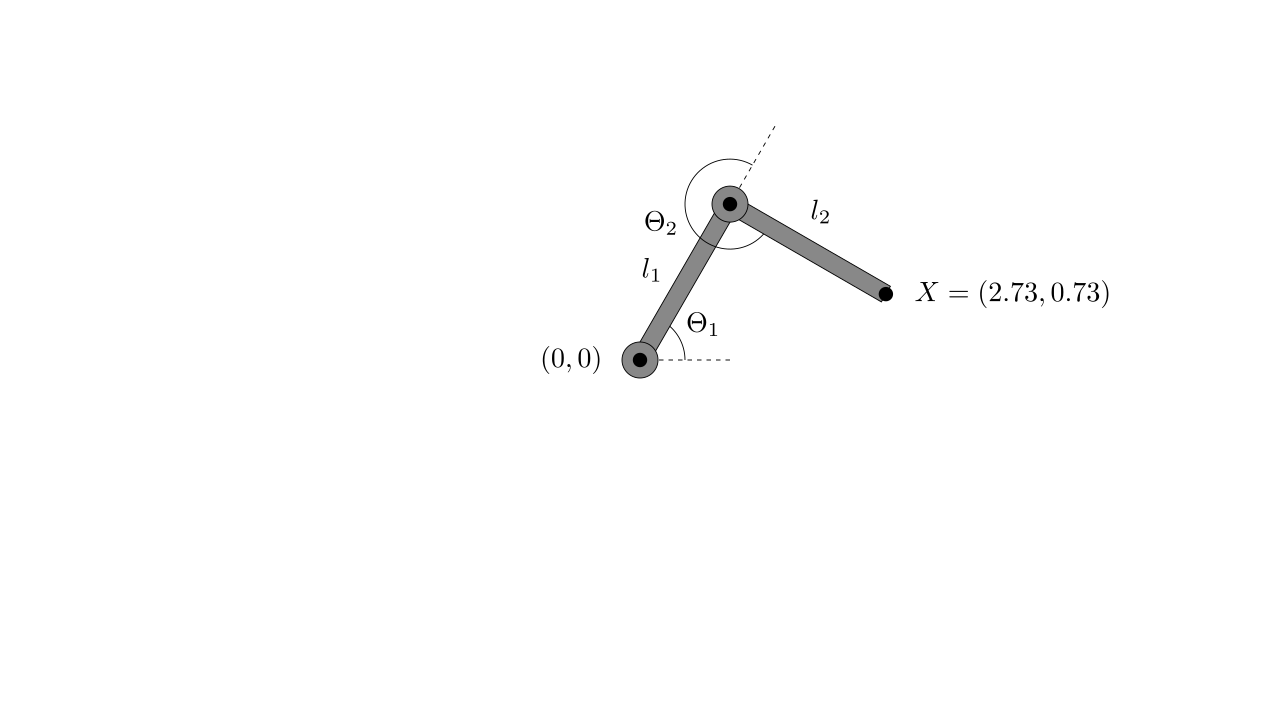

In [4]:
%%manim -qm Slide48

class Slide48(Scene):
    def construct(self):
        theta1 = ValueTracker(60)
        theta2 = ValueTracker(270)
        arm2 = Arm(2, theta2.get_value(), Dot())
        arm1 = Arm(2, theta1.get_value(), arm2)

        l1 = MathTex(r"\l_1").next_to(arm1.stick.point_from_proportion(0.25), LEFT)
        l2 = MathTex(r"\l_2").next_to(arm1.tool.stick.point_from_proportion(0.25), UP)
        t1 = MathTex(r"\Theta_1").move_to(arm1.get_arc_label_pos())
        t2 = MathTex(r"\Theta_2").move_to(arm1.tool.get_arc_label_pos())

        origin = MathTex("(0, 0)").next_to(arm1.joint, LEFT)
        X = MathTex(f"X=({arm1.tool.end.get_x():.2f}, {arm1.tool.end.get_y():.2f})").next_to(arm1.tool.end, RIGHT)

        self.add(arm1, l1, l2, t1, t2, origin, X)


Animálás az "unalmas" példával. Ez hosszabb ideig fut, mert minden frame-hez TeX-el rendereli a végeszköz koordinátáit. Hozzá kell addni a `Scene`-hez a `ValueTracker`-eket, különben nem kerül meghívásra az updater függvényük

In [25]:
%%manim -qm Slide51

def from_angular_speed(radps: float):
    def updater(x: Mobject, dt: float):
        return x.increment_value(radps * 180 * dt)
    return updater

class Slide51(Scene):
    def construct(self):
        theta1 = ValueTracker(60)
        theta2 = ValueTracker(250)
        arm2 = Arm(2, theta2.get_value(), Dot())
        arm1 = Arm(2, theta1.get_value(), arm2)
        
        arm1.add_updater(
            lambda x: x.become(Arm(2, theta1.get_value(), arm2.update()))
        )
        arm2.add_updater(
            lambda x: x.become(Arm(2, theta2.get_value(), Dot()))
        )

        l1 = MathTex(r"\l_1")
        l1.add_updater(lambda x: x.next_to(arm1.stick.point_from_proportion(0.25), LEFT), call_updater=True)
        l2 = MathTex(r"\l_2")
        l2.add_updater(lambda x: x.next_to(arm1.tool.stick.point_from_proportion(0.25), UP), call_updater=True)
        t1 = MathTex(r"\Theta_1")
        t1.add_updater(lambda x: x.move_to(arm1.get_arc_label_pos()), call_updater=True)
        t2 = MathTex(r"\Theta_2")
        t2.add_updater(lambda x: x.move_to(arm1.tool.get_arc_label_pos()), call_updater=True)

        X = MathTex("")
        X.add_updater(
            lambda x: x.become(MathTex(f"X=({arm1.tool.end.get_x():.2f}, {arm1.tool.end.get_y():.2f})").next_to(arm1.tool.end, RIGHT))
        )

        self.add(arm1, l1, l2, t1, t2, X, theta1, theta2)
        u1 = from_angular_speed(1.2)
        u2 = from_angular_speed(-0.1)
        theta1.add_updater(u1)
        theta2.add_updater(u2)
        self.wait(4)

Manim Community v0.20.1

És akkor jöjjön a polinom/spline. Ehhez először kézzel eltávolítottam az előadásból kivett görbéről a felesleges részeket, és két színre vágtam.

![theta_1](theta1.png)

![theta_2](theta2.png)

Minden oszlopban a fekete pixelek magasságának átlagát vettem egy mintának. Mivel 490 minta van, a négy másodperces 60 FPS animációhoz elegendő lineárisan interpolálni a minták között, a gyorsulásában nem lesznek érzékelhető szakadások.

In [21]:
%%manim -qm Slide50

import cv2
from scipy import interpolate

def plot_to_func(file: str):
    img = cv2.imread(file)[:, :, 0] == 0
    xs = []
    ys = []
    for col in range(img.shape[1]):
        x = col / img.shape[1]
        idx = np.argwhere(img[:, col])
        if idx.size == 0: continue
        y = idx.sum() / idx.size
        y = y / img.shape[0]
        y = 1 - y
        xs.append(x)
        ys.append(y)
    xs = np.array(xs)
    ys = np.array(ys)

    return interpolate.interp1d(xs, ys, kind="linear", bounds_error=False, fill_value=(ys[0], ys[-1]))

def from_func(f, min: float, max: float):
    def updater(x: Mobject, alpha: float):
        return x.set_value((min + float(f(alpha)) * (max-min)))
    return updater

class Slide50(Scene):
    def construct(self):
        theta1 = ValueTracker(90)
        theta2 = ValueTracker(90)
        arm2 = Arm(2, theta2.get_value(), Dot())
        arm1 = Arm(2, theta1.get_value(), arm2)
        
        arm1.add_updater(
            lambda x: x.become(Arm(2, theta1.get_value(), arm2.update()))
        )
        arm2.add_updater(
            lambda x: x.become(Arm(2, theta2.get_value(), Dot()))
        )

        l1 = MathTex(r"\l_1")
        l1.add_updater(lambda x: x.next_to(arm1.stick.point_from_proportion(0.25), LEFT), call_updater=True)
        l2 = MathTex(r"\l_2")
        l2.add_updater(lambda x: x.next_to(arm1.tool.stick.point_from_proportion(0.25), UP), call_updater=True)
        t1 = MathTex(r"\Theta_1")
        t1.add_updater(lambda x: x.move_to(arm1.get_arc_label_pos()), call_updater=True)
        t2 = MathTex(r"\Theta_2")
        t2.add_updater(lambda x: x.move_to(arm1.tool.get_arc_label_pos()), call_updater=True)

        X = MathTex("")
        X.add_updater(
            lambda x: x.become(MathTex(f"X=({arm1.tool.end.get_x():.2f}, {arm1.tool.end.get_y():.2f})").next_to(arm1.tool.end, RIGHT))
        )

        t1_f = plot_to_func("theta1.png")
        t2_f = plot_to_func("theta2.png")

        self.add(arm1, l1, l2, t1, t2, X, theta1, theta2, FunctionGraph(t1_f, x_range=[0,1]), FunctionGraph(t2_f, x_range=[0,1]).shift(UP))
        self.play(AnimationGroup(
            UpdateFromAlphaFunc(theta1, from_func(t1_f, -180, 180)),
            UpdateFromAlphaFunc(theta2, from_func(t2_f, -180, 180)),
        ), run_time=4, rate_func=linear)

Manim Community v0.20.1

111.60000000000002
97.19999999999999
3.5999999999999943
-18.00000000000003
41.400000000000006
88.19999999999999
115.20000000000005
106.19999999999999
68.39999999999998
-32.39999999999998
-43.19999999999999
-14.400000000000006
-16.200000000000017
102.60000000000002
16.20000000000013
59.400000000000006
-3.5999999999999943
99.0
-28.799999999999983
32.400000000000034
